# LLM Headline Sentiment — can a robot reading the news predict tomorrow? 🤖📰
### Letting a language model score the day's mood, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Overfitting_trap_survived%3F: Busted](https://img.shields.io/badge/Overfitting_trap_survived%3F-Busted-8b949e?style=flat-square)

Here's a very 2020s idea. Every morning, thousands of news headlines land. What if you pointed a **language model** (the ChatGPT kind) at them, asked *"is the mood good or bad?"*, and used that score to bet on tomorrow's market? It sounds like the natural upgrade of the old trick of *counting* positive and negative words — now the machine actually **reads** the sentence.

It's a real, testable method. But it's also a magnet for two classic mistakes that make *nothing* look like *something*. This notebook shows the method working on a clean, made-up world — and then shows you both traps springing shut.

> ⚠️ **This study is entirely synthetic.** There is no free, honest history of LLM-scored headlines to test on (the headlines are paywalled, and scoring old news with a modern model without cheating is genuinely hard). So this is a **method demo**, not a market claim — and by the desk's rules it can never score better than **Weak**.
>
> 📓 Want the *t*-stats, the permutation tests and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**. Not investment advice.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from llm_headline_sentiment import data, strategy as st

# The whole study is synthetic & offline — there is no real tape to load.
# EDGE world: a small day-ahead link is planted. NULL world: sentiment is noise vs the future.
EDGE, _ = data.synthetic_series(seed=588)          # beta>0 planted (the positive control)
NULL, _ = data.synthetic_series(beta=0.0, seed=588)
print("synthetic tape:", len(EDGE), "business days | edge fp",
      data.fingerprint(EDGE), "| null fp", data.fingerprint(NULL))
print("NOTE: synthetic-only study -> SIGNAL axis is capped at WEAK by construction.")


synthetic tape: 1500 business days | edge fp 06461296a1f8 | null fp 802a27d1a3e5
NOTE: synthetic-only study -> SIGNAL axis is capped at WEAK by construction.


## The answer first 🎯

| Question | Answer |
|---|---|
| Can the method work *in principle*? | **Yes.** On a clean world where the mood really does nudge tomorrow, the honest pipeline catches it (a *t*-stat of **+6.33**, odds of a fluke about 1-in-2000). |
| Can we prove it works on *real* markets? | **No — not here.** There's no honest free tape of dated LLM headline scores, so this stays a demo. Capped at **Weak**. |
| What's the catch, trap #1? | **Try enough recipes and noise looks like gold.** With **40 pure-noise** sentiment signals, the best one looks 'significant' (*p* = 0.007) — but it's a mirage: do it on noise 25 times and you 'win' **84%** of the time. |
| Trap #2? | **Cheating with hindsight.** Score the headlines *after* you know how the day went and the signal balloons (a *t* of 6.33 → **16.1**) — but no trader could have used it. |

> The method is real; the hype usually isn't. Most "AI predicts the market" headlines are one of these two traps wearing a nice suit.

## 1 · The claim

> *"An LLM reads today's news headlines, scores the mood, and that score forecasts tomorrow's market."* — the modern LLM-sentiment pitch (Lopez-Lira & Tang 2023), the context-aware descendant of counting good/bad words (Tetlock 2007; Loughran-McDonald 2011).

The intuition: a bad-news day should tilt the odds for tomorrow. Old-school sentiment just tallied scary words; an LLM understands *"not as bad as feared"* is actually **good** news. Richer reading → better signal. That's the hope.

## 2 · So what?

If it worked and you could trade it, it would be a money machine — which is exactly why you should be suspicious. The desk has already taken apart curated news-tone ([259](../../259-news-tone/)), survey sentiment ([257](../../257-aaii-sentiment/)) and buzz ([335](../../335-buzz-sentiment-etf/)). Here we go after the **LLM method itself** — not to debunk the idea, but to show the two traps that make it *look* far better than it is.

## 3 · How would we even know?

1. **Build a clean world.** We *simulate* daily mood scores and returns, with a dial. Turn the dial up and mood genuinely nudges tomorrow (a real edge); turn it to zero and mood is pure noise.
2. **Check the machine is honest.** On the edge world it should find the signal; on the noise world it should find *nothing*.
3. **Spring the traps.** Then we (a) try dozens of sentiment recipes on pure noise and report the winner, and (b) 'cheat' by scoring the news with hindsight — and watch fake signals appear.

*Timing:* today's mood is used to trade **tomorrow** — one day's lag, no peeking. That's the only honest way; the trap version peeks on purpose to show you the damage.

## 4 · The teardown — let's actually look

**First: does the machine catch a *real* edge, and stay quiet on noise?**

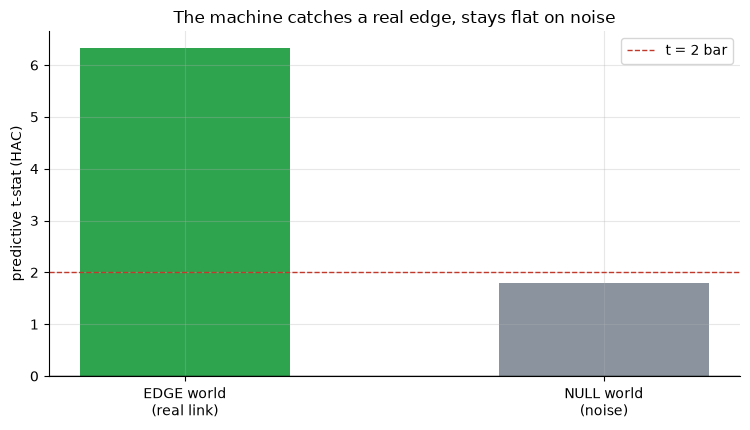

EDGE: t +6.33, explains 2.7% of tomorrow
NULL: t +1.79 (below the bar)


In [2]:
reg_edge = st.predictive_regression(EDGE['sentiment'], EDGE['forward_ret'])
reg_null = st.predictive_regression(NULL['sentiment'], NULL['forward_ret'])
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['EDGE world\n(real link)','NULL world\n(noise)'],
       [reg_edge['t'], reg_null['t']], color=[GREEN, GREY], width=.5)
ax.axhline(2, ls='--', c=RED, lw=1, label='t = 2 bar')
ax.axhline(0, c='k', lw=1); ax.set_ylabel('predictive t-stat (HAC)')
ax.set_title('The machine catches a real edge, stays flat on noise'); ax.legend()
plt.tight_layout(); plt.show()
print(f"EDGE: t {reg_edge['t']:+.2f}, explains {reg_edge['r2']*100:.1f}% of tomorrow")
print(f"NULL: t {reg_null['t']:+.2f} (below the bar)")

So the pipeline is honest: on the edge world it reads *t* **+6.33** (explains ~2.7% of tomorrow's move — small but real); on the noise world it reads *t* **+1.79**, below the bar. Good. **Now the traps.**

**Trap 1 — 'report the best prompt.'** A researcher rarely tries one recipe; they try many (different prompts, models, ways of averaging) and headline the winner. Watch what happens when we try **40 recipes that are all pure noise**:

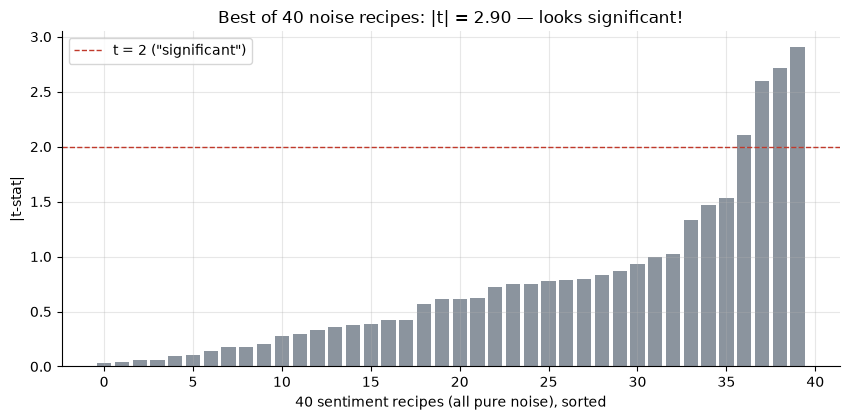

Best-of-40 |t| = 2.90 on PURE NOISE. Try enough and one always wins.


In [3]:
feats, fr, _ = data.synthetic_feature_bank(n_features=40, n_true=0, seed=588)
ts = st.all_feature_tstats(feats, fr)
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(range(len(ts)), np.sort(ts), color=GREY, width=.8)
ax.axhline(2, ls='--', c=RED, lw=1, label='t = 2 ('+'"significant"'+')')
ax.set_xlabel('40 sentiment recipes (all pure noise), sorted'); ax.set_ylabel('|t-stat|')
ax.set_title(f'Best of 40 noise recipes: |t| = {ts.max():.2f} — looks significant!')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Best-of-40 |t| = {ts.max():.2f} on PURE NOISE. Try enough and one always wins.')

There it is: the best of 40 **noise** recipes hits |*t*| = **2.9**, which a naive reader calls significant (*p* = 0.007). It isn't — it's the *maximum of 40 coin-flips*, which is naturally big. The quant notebook prices this properly and finds the honest *p* is **0.173** (not significant). Do the whole exercise 25 times and the naive test 'finds' a signal **84%** of the time; the honest correction: **0%**.

**Trap 2 — cheating with hindsight.** If you score the headlines *after* the market has already moved (a mood label written with the benefit of knowing the day), the 'signal' explodes — but it's unusable:

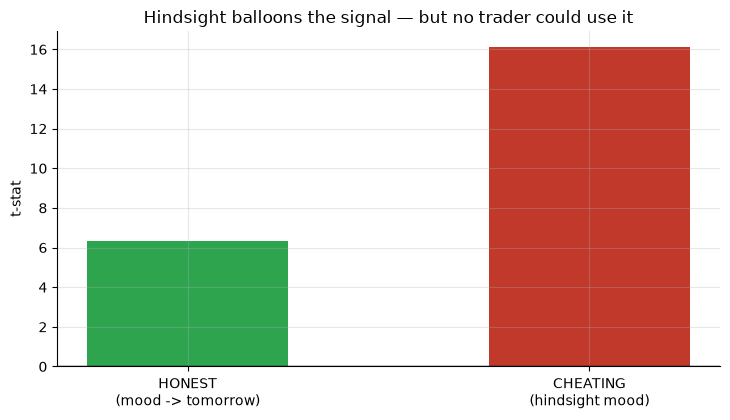

honest t +6.33  vs  hindsight t +16.10


In [4]:
la = st.look_ahead_contrast(EDGE)
fig, ax = plt.subplots(figsize=(7.4, 4.3))
ax.bar(['HONEST\n(mood -> tomorrow)','CHEATING\n(hindsight mood)'],
       [la['lagged_t'], la['contemporaneous_t']], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('t-stat')
ax.set_title('Hindsight balloons the signal — but no trader could use it')
plt.tight_layout(); plt.show()
print(f"honest t {la['lagged_t']:+.2f}  vs  hindsight t {la['contemporaneous_t']:+.2f}")

The hindsight version reads *t* **16.1** versus the honest **6.33** — roughly 2.5× bigger, for free, by reading the answer. A lot of breathless 'the AI predicted it!' results are exactly this.

## 5 · The verdict

- **Signal — Weak.** The method works on a clean world, but with no real tape it can't be certified. Capped at Weak by the desk's rules.
- **Tradability — Mirage.** The only Sharpe that survives costs is a *planted* edge in a frictionless simulation; a real day-ahead timer trades constantly, and the published 'edges' are mostly the traps above.
- **Overfitting trap survived? — Busted.** Report-the-best-recipe and hindsight-scoring both manufacture signals from nothing.

## 6 · Could you actually trade it?

Not on this evidence. Even if a small real edge exists, a one-day sign timer flips almost daily, you'd need a live, licensed, *point-in-time* LLM headline feed nobody gives away, and you'd be competing with everyone else running the same prompt. The method is worth studying; the get-rich pitch built on it usually collapses into Trap 1 or Trap 2.

## 7 · Going further 🚪

- **The sentiment cousins.** [259 News-Tone](../../259-news-tone/) (curated daily tone, the within-month placebo), [257 AAII](../../257-aaii-sentiment/) & [335 Buzz](../../335-buzz-sentiment-etf/) (survey / buzz), [566 Earnings-Call-Tone](../../566-earnings-call-tone/) (call transcripts).
- **The correction that saves you.** The quant notebook implements the *White Reality Check / Westfall-Young max-t* test — the one that turns a fake *p* = 0.007 into an honest *p* = 0.17.

*Think you've got a real LLM-headline edge? Fork this, bring a genuinely point-in-time score, and show it clears t = 2 **after** a best-of-K correction and **without** same-day leakage.*